# 01 - Data Curation
Download and explore PHI-base data, filter and clean sequences, export processed dataset.

## GoHREP:

**Goal:**

Curate a clean, balanced, and non-redundant dataset of pathogen virulence gene sequences from PHI-base, mapped to functional class categories, and formatted for ESM-2 fine-tuning.

**Hypothesis:**

Systematically filtering biological noise and reducing sequence redundancy in the PHI-base dataset will prevent model memorisation and enable the ESM-2 model to learn generalised sequence features associated with the functional classes of pathogen virulence genes.

**Rationale:**

PHI-base catalogues experimentally verified virulence genes across a broad range of fungal, oomycete, and bacterial pathogens - spanning not just effectors but transcription factors, kinases, proteases, transporters, and other proteins that contribute to infection. These functional classes are largely determined by sequence through conserved catalytic residues, domain architecture, and structural motifs, making them a more appropriate classification target for sequence-only models than virulence outcome, which is inherently relational (dependent on both the pathogen gene and the specific host context). High-quality input data is necessary for effective parameter-efficient fine-tuning. Removing fragments, pseudogenes, and highly redundant sequences ensures the model learns biological signals rather than dataset artefacts. Stratified splitting is required to handle the inherent class imbalances present in biological databases.

**Experimental Plan:**

1. **Source acquisition:** Download the most recent PHI-base metadata file and the corresponding sequence FASTA files.
2. **Parsing and target mapping:** Merge the sequence data with the metadata. Explore and define functional class categories from PHI-base annotations, consolidating the 4,137 unique free-text Function annotations into a tractable set of 8 biologically meaningful classes using keyword-based mapping.
3. **Biological quality control:** Filter sequences by length, remove sequences exceeding an acceptable threshold of ambiguous residues, and filter out unusual amino acid compositions (e.g. extreme poly-X runs).
4. **Redundancy reduction:** Cluster the filtered sequences using MMseqs2 at a 90% identity threshold. Retain only representative sequences to prevent data leakage and memorisation.
5. **Tokenization:** Process the cleaned sequences using the ESM-2 tokenizer. Apply consistent padding and truncation rules to prepare inputs for model training.
6. **Class balancing and splitting:** Perform a stratified train, validation, and test split (0.7, 0.1, 0.2), ensuring functional class proportions are preserved across splits.
7. **Data export:** Save the curated splits in the `data/splits` directory and generate a summary report detailing class distributions, retention rates, and sequence statistics.

# 0 Environment Setup

This section mounts Google Drive and installs dependencies from the GitHub repository.

In [43]:
import yaml
from google.colab import drive
import os

drive.mount('/content/drive')
PROJECT_ROOT = "/content/drive/MyDrive/esm-phi-effector"
os.chdir(PROJECT_ROOT)

config_path = os.path.join(PROJECT_ROOT, "configs/data_config.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!apt-get install -y mmseqs2 # not pip installable

if os.path.exists("requirements.txt"):
    !pip install -r requirements.txt

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libgzstream0
The following NEW packages will be installed:
  libgzstream0 mmseqs2
0 upgraded, 2 newly installed, 0 to remove and 37 not upgraded.
Need to get 7,403 kB of archives.
After this operation, 33.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libgzstream0 amd64 1.5+git20171107.9a20658-1 [7,410 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 mmseqs2 amd64 13-45111+ds-2 [7,396 kB]
Fetched 7,403 kB in 2s (3,821 kB/s)
Selecting previously unselected package libgzstream0:amd64.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../libgzstream0_1.5+git20171107.9a20658-1_amd64.deb ...
Unpacking libgzstream0:amd64 (1.5+git20171107.9a20658-1) ...
Selecting previously unselected package mmseqs2.
Preparing to unpack .../mmseq

In [3]:
import pandas as pd
from Bio import SeqIO
import shutil
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1 Data Acquisition

This section mounts Google Drive, creates the project directory structure (if it doesn't already exist), and downloads the current release of the PHI-base dataset

Sources:

- Metadata: phi-base_current.csv (Mutant phenotypes and protein IDs)
- Sequences: phi-base_current.fas (Fasta sequences for the associated proteins)
- Citation: Urban et al., 2025 "PHI-base – the multi-species pathogen–host interaction database in 2025" doi.org/10.1093/nar/gkae1084

In [4]:
raw_dir = config['paths']['raw_dir']
os.makedirs(raw_dir, exist_ok=True)

files = {
    config['paths']['metadata_file']: "https://raw.githubusercontent.com/PHI-base/data/master/releases/phi-base_current.csv",
    config['paths']['fasta_file']: "https://raw.githubusercontent.com/PHI-base/data/master/releases/phi-base_current.fas"
}

for name, url in files.items():
    file_path = os.path.join(raw_dir, name)
    if not os.path.exists(file_path):
        !wget -O {file_path} {url}

# 2 Metadata and Sequence Merging

This section loads the PHI-base metadata and FASTA sequences, then merges them into a single DataFrame using the PHI-base Accession IDs as keys.

In [47]:
# Load metadata
raw_dir = config['paths']['raw_dir']
metadata_path = os.path.join(raw_dir, config['paths']['metadata_file'])
fasta_path = os.path.join(raw_dir, config['paths']['fasta_file'])
metadata = pd.read_csv(metadata_path, low_memory=False)

# Parse sequences: Extract 'PHI:XXXX' from the middle of the complex header
sequences = {}
for record in SeqIO.parse(fasta_path, "fasta"):
    # Split header by '#' and find the part starting with 'PHI:'
    parts = record.id.split('#')
    phi_id = next((p for p in parts if p.startswith('PHI:')), None)
    if phi_id:
        sequences[phi_id] = str(record.seq)

# Map sequences using the extracted PHI IDs
metadata['sequence'] = metadata['PHI_MolConn_ID'].map(sequences)

# Remove entries without corresponding sequence data
df_raw = metadata.dropna(subset=['sequence']).copy()
df_raw['seq_length'] = df_raw['sequence'].apply(len)

print(f"Total records successfully merged: {len(df_raw)}")
print(f"Unique PHI accession IDs: {df_raw['PHI_MolConn_ID'].nunique()}")
print(f"Unique sequences: {df_raw['sequence'].nunique()}")
print(f"Duplicate sequences (same sequence, different accession): {len(df_raw) - df_raw['sequence'].nunique()}")

Total records successfully merged: 14028
Unique PHI accession IDs: 8662
Unique sequences: 8536
Duplicate sequences (same sequence, different accession): 5492


PHI-base is phenotype-centric, not gene-centric. Genes can be associated with multiple experiments, hosts, or mutant phenotypes.

# 2.2 Defining and mapping functional classes

Before defining classes, I will first explore the `Function` column to understand its structure and determine the best strategy for creating a tractable label set.

In [12]:
# How many unique functional annotations are there?
print(f"Total unique Function values: {df_raw['Function'].nunique()}")
print(f"Missing Function annotations: {df_raw['Function'].isna().sum()}")
print(f"Coverage: {df_raw['Function'].notna().sum()} / {len(df_raw)} ({df_raw['Function'].notna().sum()/len(df_raw)*100:.1f}%)")

Total unique Function values: 4137
Missing Function annotations: 181
Coverage: 13847 / 14028 (98.7%)


**Strategy 1: Filter by minumum frequency**

The simplest approach would be to keep only Function values that appear at least N times. I will check how much data is retained.

In [14]:
# How much data is retained at different frequency thresholds?
func_counts = df_raw['Function'].value_counts()

print(f"{'Min sequences':<20} {'Classes':<15} {'Sequences retained':<25} {'% retained':<15}")
print("-" * 75)
for threshold in [5, 10, 20, 50, 100]:
    surviving_classes = (func_counts >= threshold).sum()
    surviving_seqs = func_counts[func_counts >= threshold].sum()
    print(f"{threshold:<20} {surviving_classes:<15} {surviving_seqs:<25} {surviving_seqs/len(df_raw)*100:.1f}%")

Min sequences        Classes         Sequences retained        % retained     
---------------------------------------------------------------------------
5                    473             7762                      55.3%
10                   177             5814                      41.4%
20                   54              4210                      30.0%
50                   14              3026                      21.6%
100                  8               2597                      18.5%


Filtering by frequency alone results in poor data retention - even at a threshold of just 5 sequences per class, 45% of data is discarded, and the number of classes (473) remains far too large for a classification task. This approach is therefore unsuitable.

### Strategy 2: Keyword-based Mapping to Broad Biochemical Classes

Instead, I will example the most frequently annotated Function values to identify natural groupings that could be captured by keyword matching. This approach retains far more sequences while producing a tractable number of meaningful classes:

In [24]:
# Examine all Function values with at least 10 sequences to inform keyword groupings
func_counts = df_raw['Function'].value_counts()
print(f"Function values with >= 10 sequences ({(func_counts >= 10).sum()} total):\n")
print(func_counts[func_counts >= 10].to_string())

Function values with >= 10 sequences (177 total):

Function
effector protein                                                                                               926
transcription factor                                                                                           788
Zn2Cys6 transcription factor                                                                                   184
hypothetical protein                                                                                           173
type VI secretion system protein                                                                               166
type III effectors (T3E) and T3E-like genes                                                                    142
protein kinase                                                                                                 118
cell surface-associated aspartyl protease (yapsins)                                                            100
transcriptional regu

### Functional class mapping

Inspecting these annotations reveals natural groupings based on biochemical function. Critically, these groupings are appropriate for sequence-only classification because each class has distinct sequence-level signatures that ESM-2 embeddings can capture:

- **Effectors** have secretion signals, disordered regions, and host-targeting domains (Jones & Dangl, 2006)
- **Transcription factors / Regulators** have conserved DNA-binding folds such as Zn₂Cys₆ zinc clusters, bZIP domains, and helix-turn-helix motifs (MacPherson et al., 2006)
- **Proteases** are defined by catalytic residue triads/dyads and substrate-binding pockets across mechanistic classes (serine, cysteine, aspartyl, metallo-)
- **Kinases / Signalling proteins** contain conserved nucleotide-binding pockets and phosphotransfer domains
- **Cell wall / Carbohydrate-active enzymes** belong to well-characterised CAZy families with carbohydrate-binding modules and conserved catalytic domains
- **Transporters / Membrane proteins** contain transmembrane helices, substrate-binding domains, and characteristic topology
- **Secondary metabolite / Biosynthesis enzymes** are large multi-domain complexes (PKS, NRPS) with recognisable module architectures
- **Secretion system** components are structural subunits of conserved multi-protein secretion machineries (T3SS, T6SS, T5SS/autotransporter, Tat pathway)

Entries annotated as hypothetical, uncharacterised, or unknown are dropped as they carry no functional signal for the model to learn. A small number of "putative" annotations with unambiguous domain architecture (e.g. "putative transcription factor") are recovered before filtering.

#### How these groupings were generated and verified

An initial keyword-to-class mapping was generated by an LLM (Claude Sonnet 4) and then subjected to systematic review using Claude Opus 4.6. Every keyword was evaluated individually against the PHI-base annotation frequency distribution and peer-reviewed literature. This review identified several misclassifications in the initial mapping that would have introduced label noise into the training data:

- Broad enzyme-class keywords (`dehydrogenase`, `reductase`, `oxidase`) were removed from Secondary metabolite / Biosynthesis, as they captured primary metabolism enzymes (e.g. NADH dehydrogenase, succinate dehydrogenase, nitrate reductase) that are structurally unrelated to secondary metabolite biosynthetic enzymes.
- `metalloprotein` was corrected to `metalloproteinase`/`metalloprotease` in the Protease class, since metalloproteins broadly include non-protease metal-binding proteins.
- `autophagy` and `beta-lactamase` were removed from Protease: ATG proteins are kinases and ubiquitin-like conjugation enzymes (Nakatogawa et al., 2009), while beta-lactamases hydrolyse β-lactam rings rather than peptide bonds (Bush & Jacoby, 2010).
- NADPH oxidase and catalase were reclassified from Secondary metabolite to Kinase / Signalling, as these are ROS metabolism enzymes involved in oxidative stress signalling during host-pathogen interactions (Egan et al., 2007; Heller & Tudzynski, 2011).
- Siderophore-related keywords were moved from Transporter to Secondary metabolite / Biosynthesis, since the annotated proteins are predominantly NRPS-derived biosynthetic enzymes rather than transport receptors.
- The keyword `lyst` (lysosomal trafficking regulator) was removed from TF/Regulator as a misidentification of `lysr` (LysR-type transcriptional regulators; Maddocks & Oyston, 2008).

The full keyword-by-keyword review with confidence ratings and literature citations is available in [Supplementary File: `https://github.com/joshuandwilliams/esm-phi-effector/tree/main/docs/PHI-base Functional Class Keyword Review.md`].

#### Defined classes

| Class | Rationale | Example annotations |
|---|---|---|
| **Effector** | Secreted virulence proteins with host-targeting domains | effector protein, type III effector, TAL-effector, plant avirulence determinant, dense granule protein |
| **Secretion system** | Structural components of protein secretion machineries | type VI secretion system, type III secretion, autotransporter, Sec-independent protein translocase |
| **Transcription factor / Regulator** | DNA-binding and chromatin-modifying regulators of gene expression | transcription factor, Zn2Cys6, bZip, response regulator, sigma factor, histone deacetylase, DNA methyltransferase |
| **Protease** | Defined by catalytic residues and substrate-binding pockets | serine protease, cysteine protease, aspartyl protease, subtilisin-like, calpain, metalloproteinase |
| **Kinase / Signalling** | Nucleotide-binding, phosphotransfer, and signal transduction domains | protein kinase, MAP kinase, GPCR, phosphodiesterase, NADPH oxidase, F-box protein |
| **Cell wall / Carbohydrate-active** | CAZy family enzymes with carbohydrate-binding and catalytic domains | chitin synthase, xylanase, pectate lyase, glycoside hydrolase, trehalase, cutinase |
| **Transporter / Membrane** | Transmembrane helices and substrate-binding domains | ABC transporter, efflux pump, outer membrane protein, Ca2+ pump, divalent metal transporter |
| **Secondary metabolite / Biosynthesis** | Large multi-domain enzyme complexes for specialised metabolism | polyketide synthase, NRPS, phenazine biosynthesis, enniatin synthase, siderophore biosynthesis |

In [27]:
def map_functional_class(func):
    """
    Map free-text PHI-base Function annotations to broad biochemical classes
    using keyword matching. Returns None for unknown/hypothetical entries,
    which are subsequently dropped.
    """
    if pd.isna(func):
        return None

    func_lower = func.lower()

    # ── Handle recoverable putative annotations before the unknown filter ──
    putative_recoverable = [
        'putative transcription factor', 'putative transcriptional regulator'
    ]
    if any(k in func_lower for k in putative_recoverable):
        return 'Transcription factor / Regulator'

    # ── Unknown / hypothetical → drop ──
    unknown_keywords = [
        'hypothetical', 'uncharacterized', 'uncharacterised', 'unknown',
        'conserved hypothetical', 'putative'
    ]
    if any(k in func_lower for k in unknown_keywords):
        return None

    # ── Secretion system — apparatus that enables effector delivery ──
    # T3SS: Galán et al., 2014, Nature
    # T6SS: Cianfanelli et al., 2016, Trends Microbiol
    # Tat/Sec-independent: Palmer & Berks, 2012, Nature Rev Microbiol
    secretion_keywords = [
        'type vi secretion', 'type iii secretion', 'type iv pili',
        'secretion system', 'sec-independent', 'protein translocase',
        'autotransporter'
    ]
    if any(k in func_lower for k in secretion_keywords):
        return 'Secretion system'

    # ── Effector — secreted virulence/avirulence proteins ──
    # Jones & Dangl, 2006, Nature (zigzag model)
    # Boch & Bonas, 2010, Annu Rev Phytopathol (TAL effectors)
    # Hakimi et al., 2017, Clin Microbiol Rev (dense granule proteins)
    effector_keywords = [
        'effector', 'avirulence', 'avr', 'tal-effector', 'tal effector',
        'type iii effector', 't3e', 'secreted effector', 'dense granule',
        'host-selective toxin', 'virulence factor'
    ]
    if any(k in func_lower for k in effector_keywords):
        return 'Effector'

    # ── Transcription factor / Regulator ──
    # MacPherson et al., 2006, Microbiol Mol Biol Rev (Zn2Cys6)
    # Maddocks & Oyston, 2008, Microbiology (LysR)
    # Gruber & Gross, 2003, Annu Rev Microbiol (sigma factors)
    # Law & Jacobsen, 2010, Nature Rev Genet (DNA methyltransferases)
    # Allen & Taatjes, 2015, Nature Rev Mol Cell Biol (Mediator complex)
    tf_keywords = [
        'transcription factor', 'transcriptional regulator', 'transcriptional repressor',
        'transcription regulator', 'transcriptional regulatory', 'dna-binding',
        'zn2cys6', 'bzip', 'b-zip', 'lysr',
        'response regulator', 'two-component', 'regulatory protein',
        'sigma factor', 'rna polymerase sigma', 'alternative sigma',
        'regulatory system', 'regulator',
        'histone deacetylase', 'histone acetyltransferase',
        'dna methyltransferase',  # epigenetic regulation of transcription
        'mediator subunit'         # transcription co-activator complex
    ]
    if any(k in func_lower for k in tf_keywords):
        return 'Transcription factor / Regulator'

    # ── Protease ──
    # Fixed: metalloprotein → metalloproteinase/metalloprotease
    # Removed: autophagy (ATG proteins are not proteases)
    # Removed: beta-lactamase (hydrolyses beta-lactam ring, not peptide bonds)
    protease_keywords = [
        'protease', 'proteinase', 'peptidase', 'subtilisin', 'staphopain',
        'cysteine protease', 'serine protease', 'aspartyl protease',
        'metalloproteinase', 'metalloprotease',  # fixed from 'metalloprotein'
        'endoprotease', 'glutamyl endopeptidase',
        'calpain',
        'signal peptidase', 'lipoprotein signal peptidase'  # SPase family serine proteases
    ]
    if any(k in func_lower for k in protease_keywords):
        return 'Protease'

    # ── Kinase / Signalling ──
    # Hengge, 2009, Nature Rev Microbiol (c-di-GMP/PDE signalling)
    # Römling et al., 2013, Microbiol Mol Biol Rev (diguanylate cyclase)
    # Jonkers & Rep, 2009, Mol Plant Pathol (F-box in fungal virulence)
    # Egan et al., 2007, Mol Microbiol (Nox NADPH oxidases in fungi)
    # Removed: 'signal' (too broad, catches signal peptidases)
    # Removed: 'two-component' (dead code, already caught by TF/Regulator)
    kinase_keywords = [
        'kinase', 'phosphatase', 'phosphodiesterase', 'phospholipase',
        'gpcr', 'g-protein', 'g protein', 'g alpha',
        'map kinase', 'mapk', 'mitogen-activated',
        'adenylate cyclase', 'diguanylate cyclase',
        'quorum sensing', 'chemotaxis',
        'autophagy',          # ATG1 is a kinase; regulated by TOR signalling
        'nadph oxidase',      # ROS signalling enzyme
        'catalase',           # ROS detoxification / oxidative stress signalling
        'superoxide dismutase',  # antioxidant enzyme
        'f-box',              # SCF E3 ubiquitin ligase signalling component
        'ubiquitin ligase',   # protein turnover in signalling
        'gtpase',             # GTPase signalling (Rho, Ras family)
    ]
    if any(k in func_lower for k in kinase_keywords):
        return 'Kinase / Signalling'

    # ── Cell wall / Carbohydrate-active ──
    # Roncero, 2002, Curr Genet (chitin synthases)
    # Kolattukudy, 1985, Annu Rev Phytopathol (cutinases)
    # Elbein et al., 2003, Glycobiology (trehalase)
    cw_keywords = [
        'chitin', 'xylanase', 'xylan', 'pectate', 'polygalacturonase',
        'glucan', 'glucanase', 'glucanosyltransferase', 'chitinase',
        'glycoside hydrolase', 'glycosyltransfer', 'mannosyltransfer',
        'cell wall', 'carbohydrate', 'beta-1,3', 'beta-1,4',
        'transglycosylase', 'cutinase', 'cellulose', 'amidase',
        'trehalase'
    ]
    if any(k in func_lower for k in cw_keywords):
        return 'Cell wall / Carbohydrate-active'

    # ── Transporter / Membrane ──
    # Rees et al., 2009, Nature Rev Mol Cell Biol (ABC transporters)
    # Siderophore keywords moved to Secondary metabolite (biosynthesis enzymes)
    transporter_keywords = [
        'transporter', 'transport', 'efflux pump', 'outer membrane',
        'membrane protein', 'permease', 'ca2+', 'ion channel',
        'abc transporter', 'sugar transporter', 'zinc transporter',
        'divalent metal',
        'cell envelope'  # cell surface proteins
    ]
    if any(k in func_lower for k in transporter_keywords):
        return 'Transporter / Membrane'

    # ── Secondary metabolite / Biosynthesis ──
    # Hertweck, 2009, Angew Chem (polyketide synthases)
    # Removed: dehydrogenase, reductase, oxidase, nad(p)-binding (primary metabolism)
    # Removed: nadph oxidase, catalase (moved to signalling)
    # Added: siderophore biosynthesis keywords (NRPS-derived)
    # Added: salicylate hydroxylase (degrades plant SA defence)
    sm_keywords = [
        'polyketide', 'non-ribosomal peptide', 'nrps', 'phenazine',
        'fusaric', 'mycotoxin', 'biosynthesis', 'synthetase',
        'secondary metabolite', 'enniatin',
        'methyltransferase', 'acetyltransferase',
        'siderophore', 'aerobactin', 'bacillibactin',  # siderophore biosynthesis
        'salicylate hydroxylase'  # degrades plant defence metabolite SA
    ]
    if any(k in func_lower for k in sm_keywords):
        return 'Secondary metabolite / Biosynthesis'

    # Could not map to any class
    return None


# Apply mapping
df_raw['functional_class'] = df_raw['Function'].apply(map_functional_class)

# Report mapping outcome
total = len(df_raw)
mapped = df_raw['functional_class'].notna().sum()
unmapped = df_raw['functional_class'].isna().sum()

print(f"Total sequences:   {total}")
print(f"Successfully mapped: {mapped} ({mapped/total*100:.1f}%)")
print(f"Dropped (unmapped):  {unmapped} ({unmapped/total*100:.1f}%)")
print(f"\nClass distribution:")
print(df_raw['functional_class'].value_counts())

Total sequences:   14028
Successfully mapped: 8290 (59.1%)
Dropped (unmapped):  5738 (40.9%)

Class distribution:
functional_class
Transcription factor / Regulator       2207
Kinase / Signalling                    1732
Effector                               1490
Transporter / Membrane                  691
Cell wall / Carbohydrate-active         599
Secondary metabolite / Biosynthesis     563
Protease                                551
Secretion system                        457
Name: count, dtype: int64


In [28]:
# What are we dropping? Check the most common unmapped Function values
unmapped = df_raw[df_raw['functional_class'].isna() & df_raw['Function'].notna()]
print(f"Unmapped but annotated (potentially recoverable): {len(unmapped)}")
print(f"Truly missing Function annotation: {df_raw['Function'].isna().sum()}\n")
print("Most common unmapped Function values:")
print(unmapped['Function'].value_counts().head(30).to_string())

Unmapped but annotated (potentially recoverable): 5557
Truly missing Function annotation: 181

Most common unmapped Function values:
Function
hypothetical protein                                              173
uncharacterized protein                                            71
conserved hypothetical protein                                     49
cold shock protein                                                 40
Na(+)-translocating NADH-quinone reductase                         30
unknown                                                            29
NAD(P)-binding domain protein                                      21
endocarditis specific antigen                                      19
flagellin                                                          18
putative short chain dehydrogenase                                 18
phage-shock protein                                                18
dicer-like protein                                                 16
uncharacterised pr

# 2.3 Initial Dataset Visualisation

This section visualises the initial dataset

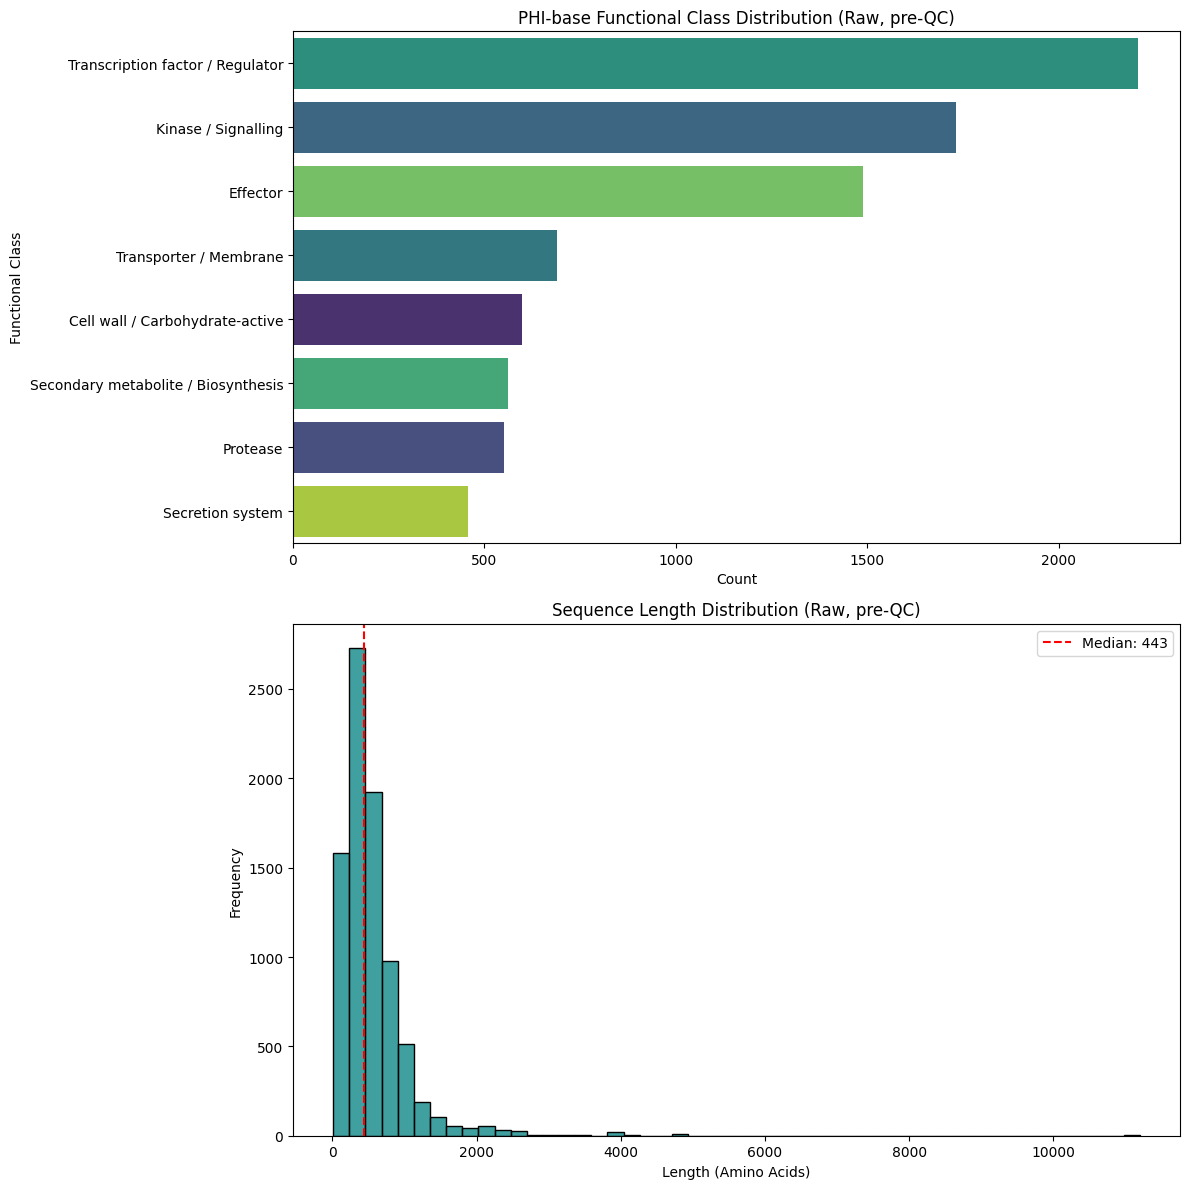

                                     count  min    max  median
functional_class                                              
Cell wall / Carbohydrate-active        599   98   2412   445.0
Effector                              1490   33   4753   325.5
Kinase / Signalling                   1732   33   4170   462.0
Protease                               551   69   2144   453.0
Secondary metabolite / Biosynthesis    563   66  11197   517.0
Secretion system                       457   31   7919   277.0
Transcription factor / Regulator      2207   11   3861   496.0
Transporter / Membrane                 691   52   2339   464.0


In [29]:
# Filter to mapped sequences only for visualisation
df_mapped = df_raw[df_raw['functional_class'].notna()].copy()

plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)
order = df_mapped['functional_class'].value_counts().index
sns.countplot(
    data=df_mapped,
    y='functional_class',
    order=order,
    palette='viridis',
    hue='functional_class',
    legend=False
)
plt.title('PHI-base Functional Class Distribution (Raw, pre-QC)')
plt.xlabel('Count')
plt.ylabel('Functional Class')

plt.subplot(2, 1, 2)
sns.histplot(df_mapped['seq_length'], bins=50, color='teal')
plt.axvline(x=df_mapped['seq_length'].median(), color='red', linestyle='--', label=f'Median: {df_mapped["seq_length"].median():.0f}')
plt.title('Sequence Length Distribution (Raw, pre-QC)')
plt.xlabel('Length (Amino Acids)')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

stats = df_mapped.groupby('functional_class')['seq_length'].agg(['count', 'min', 'max', 'median'])
print(stats)

# 3 Biological Quality Control

This section applies filters to ensure the sequences are suitable for the ESM-2 model:
- Remove rows with duplicate sequences:
  - If the same gene appears with conflicting functional classes (noisy labels), remove all rows for that gene
  - If the same gene appears with the same functional class across different hosts, randomly retain one representative row
- Remove sequence fragments and overly long outliers
- Filter sequences with excessive ambiguous residues

In [30]:
# Filter to mapped sequences only
df_mapped = df_raw[df_raw['functional_class'].notna()].copy()
print(f"Starting with mapped sequences: {len(df_mapped)}")

# 1. Remove genes with conflicting functional class labels
overlap_counts = df_mapped.groupby('PHI_MolConn_ID')['functional_class'].nunique()
conflicting_genes = overlap_counts[overlap_counts > 1].index
conflicting_rows = df_mapped['PHI_MolConn_ID'].isin(conflicting_genes)

print(f"Rows with conflicting functional class labels removed: {conflicting_rows.sum()}")
df_mapped = df_mapped[~conflicting_rows].copy()

# 2. Remove redundant rows (same gene, same class, different host)
unique_genes = df_mapped['PHI_MolConn_ID'].nunique()
redundant_rows = len(df_mapped) - unique_genes

print(f"Redundant rows removed: {redundant_rows}")
df_mapped = df_mapped.sample(frac=1, random_state=config['splitting']['random_seed']).drop_duplicates(subset=['PHI_MolConn_ID'], keep='first')

# 3. Verify all genes are now unique
print(f"Deduplicated dataset rows: {len(df_mapped)}")
is_unique = len(df_mapped) == df_mapped['PHI_MolConn_ID'].nunique()
print(f"All genes unique: {is_unique}")

Starting with mapped sequences: 8290
Rows with conflicting functional class labels removed: 31
Redundant rows removed: 3215
Deduplicated dataset rows: 5044
All genes unique: True


## Defence of filtering thresholds

**Lower Threshold (50 AA):**

PHI-base relies on literature curation of experimental evidence, so these short sequences are real secreted peptides or effectors, not spurious ORFs. However, very short peptides often lack a stable tertiary structure or interact in different ways to larger globular proteins, which means they can behave differently in the model's embedding space.

**Upper Threshold (1500 AA):**

ESM0-2 uses Rotary Position Embedding (RoPE), which allows it to theoretically extrapolate beyond its 1,024 token training context window. The 1,500 AA cutoff is primarily a hardware constraint, since the self-attention mechanism scales quadratically $O(N^2)$ with sequence length. This cutoff also helps exclude multi-domain fusions where the effector-specific signal might be diluted across thousands of unrelated residues.

**Ambiguity (0.0):**

ESM-2 uses self-attention to infer structural and evolutionary relationships between individual residues. Unknown tokens introduce significant noise and degrade the contextual embeddings for the valid surrounding regions.



In [36]:
df = df_mapped.copy()
counts = [len(df)]
print(f"Initial count: {len(df)}")

# 4. Minimum length filtering
min_len = config['filtering']['min_seq_length']
df = df[df['seq_length'] >= min_len]
counts.append(len(df))
print(f"Removed (< {min_len} aa): {counts[0] - counts[1]}")

# 5. Maximum length filtering
max_len = config['filtering']['max_seq_length']
df = df[df['seq_length'] <= max_len]
counts.append(len(df))
print(f"Removed (> {max_len} aa): {counts[1] - counts[2]}")

# 6. Ambiguous residue filtering
ambiguity_threshold = config['filtering']['max_ambiguity_fraction']
df = df[df['sequence'].str.count('X') / df['seq_length'] <= ambiguity_threshold]
counts.append(len(df))
print(f"Removed (ambiguous residues > {ambiguity_threshold*100:.0f}%): {counts[2] - counts[3]}")

# 7. Apply integer label mapping from config
mapping = {k: v for k, v in config['target_mapping'].items()}
df['label'] = df['functional_class'].map(mapping)

print(f"\nFinal sequences retained: {len(df)}")
print(f"\nClass distribution after QC:")
print(df['functional_class'].value_counts())

Initial count: 5044
Removed (< 50 aa): 9
Removed (> 1500 aa): 198
Removed (ambiguous residues > 5%): 0

Final sequences retained: 4837

Class distribution after QC:
functional_class
Transcription factor / Regulator       1642
Kinase / Signalling                    1109
Effector                                709
Transporter / Membrane                  381
Cell wall / Carbohydrate-active         290
Secondary metabolite / Biosynthesis     264
Secretion system                        233
Protease                                209
Name: count, dtype: int64


## 4 Redundancy Reduction with MMseqs2 Clustering

This section uses MMseqs2 to reduce dataset redundancy by grouping highly similar protein sequences into clusters. Retaining only a single representative sequence (centroid) from each cluster prevents data leakage between the training and hold-out test sets, ensuring the model learns generalisable biological features rather than memorising near-identical sequences.

MMseqs2 `easy-cluster` is run with a sequence identity threshold of 90% and a coverage threshold of 80% (coverage mode 1: target coverage). Note that clustering is performed in local Colab storage (`/content/mmseqs_work`) rather than directly on Google Drive, as the Drive FUSE filesystem does not support the memory-mapped files required by MMseqs2.

## Defence of filtering thresholds

**Identity (90%):**

90% sequence identity is a standard method used to prevent data leakage, similar to the UniRef90 database. It collapses minor strain-level variations, orthologs from very closely related species, or sequencing artifacts of the exact same protein into a single representitive sequence.

In [37]:
processed_dir = config['paths']['processed_dir']

absolute_path = os.path.abspath(processed_dir)
print(f"Saving files to absolute path: {absolute_path}")
print(f"Initial count: {len(df)}")

os.makedirs(processed_dir, exist_ok=True)

# Write filtered sequences to FASTA file
fasta_in = os.path.join(processed_dir, "temp_input.fasta")
with open(fasta_in, "w") as f:
    for _, row in df.iterrows():
        f.write(f">{row['PHI_MolConn_ID']}\n{row['sequence']}\n")

# Run MMseqs2 in local storage (Google Drive FUSE doesn't support mmap)
local_work = "/content/mmseqs_work"
os.makedirs(local_work, exist_ok=True)

local_fasta = os.path.join(local_work, "temp_input.fasta")
shutil.copy(fasta_in, local_fasta)

local_prefix = os.path.join(local_work, "cluster_res")
local_tmp = os.path.join(local_work, "tmp_mmseqs")
os.makedirs(local_tmp, exist_ok=True)

identity_threshold = config['clustering']['identity_threshold']
coverage_threshold = config['clustering']['coverage_threshold']
out_prefix = os.path.join(processed_dir, "cluster_res")

cmd = [
    "mmseqs", "easy-cluster",
    local_fasta, local_prefix, local_tmp,
    "--min-seq-id", str(identity_threshold),
    "-c", str(coverage_threshold),
    "--cov-mode", "1"
]

subprocess.run(cmd, check=True)

# Copy results back to Drive
for suffix in ["_cluster.tsv", "_rep_seq.fasta", "_all_seqs.fasta"]:
    src = local_prefix + suffix
    if os.path.exists(src):
        shutil.copy(src, out_prefix + suffix)

# Filter dataframe to keep only cluster centroids
tsv_out = f"{out_prefix}_cluster.tsv"
clusters = pd.read_csv(tsv_out, sep='\t', header=None, names=['representative', 'member'])

centroids = clusters['representative'].unique()
df = df[df['PHI_MolConn_ID'].isin(centroids)].copy()

print(f"Sequences remaining after clustering: {len(df)}")
print(f"\nClass distribution after clustering:")
print(df['functional_class'].value_counts())

# Clean up temporary files
for ext in ['_all_seqs.fasta', '_cluster.tsv', '_rep_seq.fasta']:
    for prefix in [out_prefix, local_prefix]:
        file_path = f"{prefix}{ext}"
        if os.path.exists(file_path):
            os.remove(file_path)
if os.path.exists(fasta_in):
    os.remove(fasta_in)
shutil.rmtree(local_work, ignore_errors=True)

Saving files to absolute path: /content/drive/MyDrive/esm-phi-effector/data/processed
Initial count: 4837
Sequences remaining after clustering: 4518

Class distribution after clustering:
functional_class
Transcription factor / Regulator       1563
Kinase / Signalling                    1007
Effector                                658
Transporter / Membrane                  370
Cell wall / Carbohydrate-active         275
Secondary metabolite / Biosynthesis     248
Secretion system                        200
Protease                                197
Name: count, dtype: int64


# 4.2 Cleaned Dataset Visualisation

This section visualises the cleaned dataset.

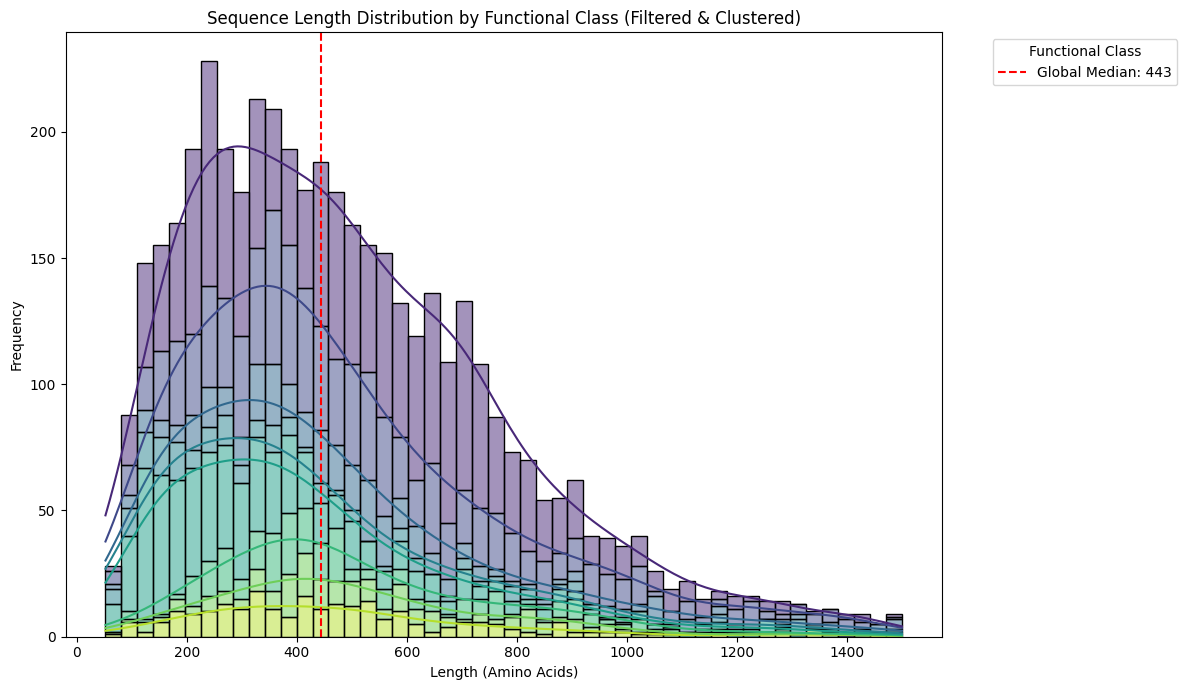

                                     count  min   max  median
functional_class                                             
Transcription factor / Regulator      1563   72  1493   509.0
Kinase / Signalling                   1007   69  1496   464.0
Effector                               658   54  1456   284.0
Transporter / Membrane                 370   52  1499   464.5
Cell wall / Carbohydrate-active        275   98  1492   425.0
Secondary metabolite / Biosynthesis    248   66  1484   434.5
Secretion system                       200   57  1500   329.0
Protease                               197   69  1372   479.0


In [39]:
# Stacked histogram of sequence lengths by functional class
plt.figure(figsize=(12, 7))
sns.histplot(
    data=df,
    x='seq_length',
    hue='functional_class',
    bins=50,
    multiple='stack',
    palette='viridis'
)
plt.axvline(
    x=df['seq_length'].median(),
    color='red',
    linestyle='--',
    label=f'Global Median: {df["seq_length"].median():.0f}'
)
plt.title('Sequence Length Distribution by Functional Class (Filtered & Clustered)')
plt.xlabel('Length (Amino Acids)')
plt.ylabel('Frequency')
plt.legend(title='Functional Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Summary statistics ordered by count (high to low)
stats = (
    df.groupby('functional_class')['seq_length']
    .agg(['count', 'min', 'max', 'median'])
    .sort_values(by='count', ascending=False)
)
print(stats)

## Takeaways

- The classes are imbalanced. Transcription factor / Regulator is the largest class (1,563 sequences), approximately 8x larger than the smallest class Protease (197 sequences).
- After functional class mapping, biological quality control, and redundancy reduction, the dataset retains 4,518 sequences - 52.9% of the original 8,536 unique sequences.
- Effectors have a notably shorter median sequence length (284 aa) compared to other classes, consistent with their biology as compact secreted proteins. Transcription factors are the longest (median 509 aa), likely reflecting their multi-domain architecture.
- The sequence length distribution is right-skewed across all classes, with the bulk of sequences falling between 100-600 aa and a long tail extending to the 1,500 aa maximum cutoff.
- Long-tail sequences are disproportionately contributed by the Transcription factor / Regulator and Kinase / Signalling classes, consistent with the larger multi-domain architectures typical of these protein families.

## Imbalanced class size strategy

The classes are imbalanced, with Transcription factor / Regulator accounting for 34.6% of the dataset and Protease accounting for only 4.4%.

**Plan A: No change**

To begin with, I will not implement any resampling for the following reasons:
1. Although accuracy can be inflated if the model simply predicts the majority class every time, I can prioritise precision-recall curves and F1-scores, which are more robust for assessing model quality on minority classes.
2. Keeping the natural data distribution helps the model learn that certain functional classes are rarer in pathogen biology.
3. ESM-2 is a powerful transformer, and with proper regularisation it may be able to learn distinct sequence features for the smaller classes without needing artificial balance.

**Plan B: Weighted Loss Functions**

If the model completely fails to predict the smaller classes during initial validation, I will implement weighted cross-entropy loss to penalise the model more for misclassifying the rarer classes. Weights will be set inversely proportional to class frequency.

**Plan C: Downsampling**

If weighted loss is insufficient, I will reduce the larger classes (Transcription factor / Regulator, Kinase / Signalling) to closer to the median class size. This plan may also be necessary if GPU memory is limiting. However, it risks discarding informative sequence diversity from the larger classes.

**Plan D: Upsampling**

Finally, I may attempt to upsample the smallest classes (Protease, Secretion system) by duplicating examples or synthesizing new ones via interpolation in embedding space. SMOTE operates on raw feature vectors and is not directly applicable to sequences - any upsampling would need to be applied after ESM-2 embedding.

# 5 Data splits

This section involves splitting the data into training, validation, and hold-out test sets

In [44]:
test_size = config['splitting']['test_size']
val_size = config['splitting']['val_size']
seed = config['splitting']['random_seed']

# Stratified split: train+val / test
df_trainval, df_test = train_test_split(
    df, test_size=test_size, random_state=seed,
    stratify=df['functional_class']
)

# Split train+val into train / val
# val_size is proportion of *total*, so adjust for the remaining data
val_frac = val_size / (1 - test_size)
df_train, df_val = train_test_split(
    df_trainval, test_size=val_frac, random_state=seed,
    stratify=df_trainval['functional_class']
)

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
print(f"\nLabel mapping: {config['target_mapping']}")
print(f"\nTrain class distribution:\n{df_train['functional_class'].value_counts()}")
print(f"\nVal class distribution:\n{df_val['functional_class'].value_counts()}")
print(f"\nTest class distribution:\n{df_test['functional_class'].value_counts()}")

Train: 3614, Val: 452, Test: 452

Label mapping: {'Effector': 0, 'Transcription factor / Regulator': 1, 'Kinase / Signalling': 2, 'Protease': 3, 'Cell wall / Carbohydrate-active': 4, 'Transporter / Membrane': 5, 'Secondary metabolite / Biosynthesis': 6, 'Secretion system': 7}

Train class distribution:
functional_class
Transcription factor / Regulator       1251
Kinase / Signalling                     805
Effector                                526
Transporter / Membrane                  296
Cell wall / Carbohydrate-active         221
Secondary metabolite / Biosynthesis     198
Secretion system                        160
Protease                                157
Name: count, dtype: int64

Val class distribution:
functional_class
Transcription factor / Regulator       156
Kinase / Signalling                    101
Effector                                66
Transporter / Membrane                  37
Cell wall / Carbohydrate-active         27
Secondary metabolite / Biosynthesis     25
P

# 6 Tokenization

This step converts biological sequences into numerical representations that the transformer architecture can process. Using the pre-trained ESM-2 tokenizer ensures each amino acid is mapped to the specific integer ID established during the model's original training, while padding and truncation ensure uniform tensor shapes required for efficient hardware acceleration.

## Strategies for handling ESM-2 sequences longer than the 1,022 AA limit (1,024 including CLS and EOS)

**Strategy 1: Truncation**

The default behaviour in the ESM extraction scripts. Lossy and may lose information meaningful for prediction.

**Strategy 2: Sliding Window with Averaging**

Split the sequence into non-overlapping chunks that fit within the context window. Extract embeddings for each chunk independently, then aggregate. Oliveira et al., 2025 (https://doi.org/10.5753/bsb.2024.244804). Normally recommended to process with length-weighted averaging.

Residues near chunk boundaries lose long-range context - overlapping windows can mitigate this - process overlapping chunks and average the embeddings for residues covered by multiple windows.

**Strategy 3: Domain-Level Extraction**

Use functional annotations (e.g. Pfam domains) to extract biologically meaningful sub-regions that fit within the context window (e.g. think NLR NB-ARC domain).

**Strategy 4: Architectural Modifications**

Oliveira et al., 2025 also adapted ESM-2 architectures using Longformer-style local attention to double the context window. These models are available on HuggingFace. Long versions were not available for the largest ESM-2 variants (T36 and T48).

**Strategy 5: Random Cropping**

During ESM-2 pretraining, the original approach used random cropping for sequences exceeding the context window. This could also be applied during fine tuning - each epoch samples a different random crop of long sequences, so the model eventually sees different parts of the protein across training steps. This provides a form of data augmentation.

## Configuration choices

**ESM-2 Model ("facebook/esm2_t30_150M_UR50D"):**

The t30 version is a 30-layer transformer with 150 million parameters. This is a middle-ground in terms of size, which provides high-quality biological representations while remaining computationally manageable. UR50D indicates the model was trained on the UniRef50 database.

**Max token length (1,024):**

This defines the fixed size for all input vectors. In JAX, the XLA (accelerated linear algebra) compiler requires static array shapes to optimise performance. By padding shorter sequences and truncating longer ones to 1,024 tokens, it avoids constantly recompiling the execution graph and ensure the model can handle the maximum context window supported by ESM-2.

## Generate frozen embeddings

In [45]:
from transformers import AutoTokenizer, AutoModel
import torch

model_name = config['tokenization']['esm_model']
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).eval().to("cuda")

MAX_LEN = config['tokenization']['max_token_length'] - 2  # 1024 - CLS - EOS

def get_embeddings(sequences, method="truncate", overlap=0, batch_size=8):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(sequences), batch_size):
            batch_seqs = sequences[i:i + batch_size]

            for seq in batch_seqs:
                if len(seq) <= MAX_LEN or method == "truncate":
                    # Truncation: short seqs pass through, long seqs get clipped
                    inputs = tokenizer(seq, return_tensors="pt", truncation=True,
                                       max_length=MAX_LEN + 2).to("cuda")
                    output = model(**inputs).last_hidden_state
                    emb = output[0, 1:-1].mean(dim=0)

                elif method == "sliding":
                    # Non-overlapping sliding window
                    chunks = [seq[j:j + MAX_LEN] for j in range(0, len(seq), MAX_LEN)]
                    chunk_embs, chunk_lens = [], []
                    for chunk in chunks:
                        inputs = tokenizer(chunk, return_tensors="pt", truncation=True,
                                           max_length=MAX_LEN + 2).to("cuda")
                        output = model(**inputs).last_hidden_state
                        chunk_embs.append(output[0, 1:-1].mean(dim=0))
                        chunk_lens.append(len(chunk))
                    weights = torch.tensor(chunk_lens, dtype=torch.float, device="cuda")
                    weights /= weights.sum()
                    emb = (torch.stack(chunk_embs) * weights.unsqueeze(1)).sum(dim=0)

                elif method == "sliding_overlap":
                    # Overlapping sliding window
                    step = MAX_LEN - overlap
                    chunks = [seq[j:j + MAX_LEN] for j in range(0, len(seq), step)]
                    chunk_embs, chunk_lens = [], []
                    for chunk in chunks:
                        inputs = tokenizer(chunk, return_tensors="pt", truncation=True,
                                           max_length=MAX_LEN + 2).to("cuda")
                        output = model(**inputs).last_hidden_state
                        chunk_embs.append(output[0, 1:-1].mean(dim=0))
                        chunk_lens.append(len(chunk))
                    weights = torch.tensor(chunk_lens, dtype=torch.float, device="cuda")
                    weights /= weights.sum()
                    emb = (torch.stack(chunk_embs) * weights.unsqueeze(1)).sum(dim=0)

                all_embeddings.append(emb.cpu())

            if (i // batch_size) % 50 == 0:
                print(f"  Processed {min(i + batch_size, len(sequences))}/{len(sequences)}")

    return torch.stack(all_embeddings)

# Generate and save embeddings for all three methods
emb_base_dir = os.path.join(config['paths']['splits_dir'], "frozen_embeddings")

methods = {
    "truncate":        {"method": "truncate", "overlap": 0},
    "sliding":         {"method": "sliding", "overlap": 0},
    "sliding_overlap": {"method": "sliding_overlap", "overlap": 200},
}

for name, params in methods.items():
    print(f"\n{'='*50}")
    print(f"Generating embeddings: {name}")
    print(f"{'='*50}")

    save_dir = os.path.join(emb_base_dir, name)
    os.makedirs(save_dir, exist_ok=True)

    print("  Train...")
    X_train = get_embeddings(df_train['sequence'].tolist(), **params)
    print("  Val...")
    X_val = get_embeddings(df_val['sequence'].tolist(), **params)
    print("  Test...")
    X_test = get_embeddings(df_test['sequence'].tolist(), **params)

    torch.save({
        'X_train': X_train, 'y_train': torch.tensor(df_train['label'].values),
        'X_val': X_val, 'y_val': torch.tensor(df_val['label'].values),
        'X_test': X_test, 'y_test': torch.tensor(df_test['label'].values),
        'label_mapping': config['target_mapping'],
        'method': name,
        'overlap': params['overlap'],
        'model': model_name,
    }, os.path.join(save_dir, f"embeddings_{name}.pt"))

    print(f"  Saved to {save_dir}/embeddings_{name}.pt | Shape: {X_train.shape}")

print(f"\nAll embeddings saved to: {emb_base_dir}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Generating embeddings: truncate
  Train...
  Processed 8/3614
  Processed 408/3614
  Processed 808/3614
  Processed 1208/3614
  Processed 1608/3614
  Processed 2008/3614
  Processed 2408/3614
  Processed 2808/3614
  Processed 3208/3614
  Processed 3608/3614
  Val...
  Processed 8/452
  Processed 408/452
  Test...
  Processed 8/452
  Processed 408/452
  Saved to data/splits/frozen_embeddings/truncate/embeddings_truncate.pt | Shape: torch.Size([3614, 640])

Generating embeddings: sliding
  Train...
  Processed 8/3614
  Processed 408/3614
  Processed 808/3614
  Processed 1208/3614
  Processed 1608/3614
  Processed 2008/3614
  Processed 2408/3614
  Processed 2808/3614
  Processed 3208/3614
  Processed 3608/3614
  Val...
  Processed 8/452
  Processed 408/452
  Test...
  Processed 8/452
  Processed 408/452
  Saved to data/splits/frozen_embeddings/sliding/embeddings_sliding.pt | Shape: torch.Size([3614, 640])

Generating embeddings: sliding_overlap
  Train...
  Processed 8/3614
  Processed 4

## Fine-tuning dataset

In [46]:
from torch.utils.data import Dataset

class ProteinDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=1022):
        self.sequences = df['sequence'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]

        if len(seq) <= self.max_len:
            inputs = self.tokenizer(seq, truncation=True, max_length=self.max_len + 2,
                                    padding="max_length", return_tensors="pt")
        else:
            # Random crop for augmentation during fine-tuning
            start = torch.randint(0, len(seq) - self.max_len + 1, (1,)).item()
            crop = seq[start:start + self.max_len]
            inputs = self.tokenizer(crop, truncation=True, max_length=self.max_len + 2,
                                    padding="max_length", return_tensors="pt")

        return {k: v.squeeze(0) for k, v in inputs.items()}, self.labels[idx]

tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = ProteinDataset(df_train, tokenizer, max_len=MAX_LEN)
val_dataset = ProteinDataset(df_val, tokenizer, max_len=MAX_LEN)
test_dataset = ProteinDataset(df_test, tokenizer, max_len=MAX_LEN)

# Save datasets
ft_dir = os.path.join(config['paths']['splits_dir'], "fine_tuning_dataset")
os.makedirs(ft_dir, exist_ok=True)

for split_name, split_df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    torch.save({
        'sequences': split_df['sequence'].tolist(),
        'labels': split_df['label'].tolist(),
        'ids': split_df['PHI_MolConn_ID'].tolist(),
        'functional_classes': split_df['functional_class'].tolist(),
        'label_mapping': config['target_mapping'],
        'model': model_name,
    }, os.path.join(ft_dir, f"{split_name}.pt"))

print(f"Fine-tuning datasets saved to: {ft_dir}")
print(f"  train.pt: {len(train_dataset)} samples")
print(f"  val.pt:   {len(val_dataset)} samples")
print(f"  test.pt:  {len(test_dataset)} samples")

# Sanity check
inputs, label = train_dataset[0]
print(f"\nSanity check - Input IDs shape: {inputs['input_ids'].shape}, Label: {label}")

Fine-tuning datasets saved to: data/splits/fine_tuning_dataset
  train.pt: 3614 samples
  val.pt:   452 samples
  test.pt:  452 samples

Sanity check - Input IDs shape: torch.Size([1024]), Label: 1
